In [3]:
import numpy as np
import matplotlib.pyplot as pl
import time
from joblib import Parallel, delayed

In [4]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

In [5]:
def beta_step(beta, f0, f_max, phi_thresh):
    temp0 = beta**2*(5*phi_thresh)/(6*pi*f0)
    temp1 = (-5/8-3/8*(f0/f_max)**(8/3))/(f0/f_max)+1
    return -temp0/temp1

In [6]:
def steps_analytic(step, beta0, k):
    return 1/(-k*step+1/beta0)

In [38]:
f0 = 20
Mc = 1e-4 * 2e30
f_max = 200
beta = const*f0**(8/3)*Mc**(5/3)
phi_thresh=pi
beta_max = const*f0**(8/3)*(1e-1*2e30)**(5/3)

In [39]:
beta_step(beta, f0, f_max, phi_thresh)/beta

2.93131592468842e-12

In [40]:
k=-(5*phi_thresh)/(6*pi*f0)/((-5/8-3/8*(f0/f_max)**(8/3))/(f0/f_max)+1)
step_space = np.logspace(0, 12, 1000)
beta_arr = steps_analytic(step_space, beta, k)

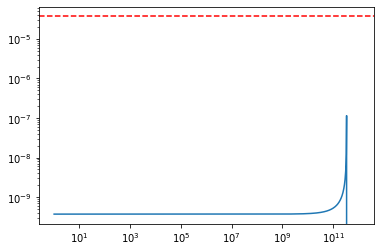

In [41]:
pl.loglog(step_space, beta_arr)
pl.axhline(beta_max, c='r', ls='--')
# pl.axvline(3e10, c='r', ls='--')

Specific arguments

In [44]:
f0 = 20
Mc = 4e-3 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
beta_max = const*200**(8/3)*(1e-1*2e30)**(5/3)

In [45]:
np.log10(5e-3)

-2.3010299956639813

In [46]:
print(beta, beta_max)

1.7306170268140428e-07 0.017169895555741808


In [47]:
steps=0
beta_arr=[]
while beta<beta_max:
    steps+=10000
    beta_arr.append(beta)
    beta += 10000*beta_step(beta, f0, f_max, phi_thresh)

7.292900E+08


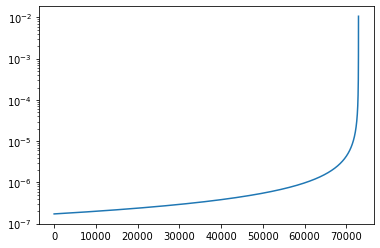

In [48]:
pl.semilogy(beta_arr)
print('%E' % steps)

## With time grid

In [15]:
def t_max_calc(f0, beta, f_max):
    temp0 = 0.375/beta
    temp1 = 1-(f0/f_max)**(8/3)
    return temp0*temp1

In [16]:
f0 = 20
Mc = 1e-2 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
beta_max = const*200**(8/3)*(1e-1*2e30)**(5/3)

In [17]:
steps=0
beta_arr=[]
while beta<beta_max:
    beta_arr.append(beta)
    beta += 1000*beta_step(beta, f0, f_max, phi_thresh)
    steps += 1000*(1e7/t_max_calc(f0, beta, f_max))

In [18]:
print('%E' % steps)

3.460623E+10
